# Task 2：Clustering 實作 — 網路入侵偵測（Network Intrusion Detection）

## 專案目標

本 Notebook 以 **無監督學習（Unsupervised Learning）** 中的分群（Clustering）演算法，對網路連線資料進行分群，嘗試在**沒有使用標籤**的情況下，自動區分「正常流量」與「各類攻擊行為」。

## 資安場景鎖定：網路入侵偵測

Clustering 在網路入侵偵測（Network Intrusion Detection）上的優勢：

1. **不需要攻擊標籤**：新型態攻擊（Zero-day）沒有已知標籤，Clustering 可直接在原始流量中找出異常群集。
2. **自動發現行為模式**：相似連線（例如同一種 DoS 攻擊）會自然聚在一起，便於後續人工檢視。
3. **雜訊點即異常候選**：DBSCAN 等演算法會把「不屬於任何密集區」的點標為雜訊，這些點往往就是稀有攻擊。

## 資料集：NSL-KDD-like（KDDCup'99 去重版）

- **來源**：Hugging Face Hub — [`Pakapak/kdd_cup_1999`](https://huggingface.co/datasets/Pakapak/kdd_cup_1999)
  - 資料集網址：<https://huggingface.co/datasets/Pakapak/kdd_cup_1999>
- **處理**：對原始 494,020 筆進行去重（drop_duplicates），得到約 145k 筆，等效於官方 NSL-KDD 去重後的規模與分佈。
- 作業要求的資料來源為 Kaggle 或 Hugging Face — 此處採用 HF，免 API key，方便重現。


## NSL-KDD 資料集簡介

NSL-KDD 資料集是網路入侵偵測領域的經典公開資料集，改良自 1999 KDD Cup 競賽資料（去除大量重複紀錄）。每一筆代表一個網路連線，包含 **41 個特徵（feature）** 與 **標籤（label）**。

### 特徵分類

| 類型 | 範例欄位 | 說明 |
|------|---------|------|
| 基本連線特徵 | `duration`, `protocol_type`, `service`, `flag`, `src_bytes`, `dst_bytes` | 連線持續時間、協定、服務、封包大小 |
| 內容特徵（Content） | `hot`, `num_failed_logins`, `logged_in`, `root_shell` | 登入行為、檔案操作 |
| 時間統計特徵 | `count`, `serror_rate`, `same_srv_rate` | 過去 2 秒內同主機／同服務連線統計 |
| 主機統計特徵 | `dst_host_count`, `dst_host_same_srv_rate` | 對同一目的主機的歷史統計 |

### 類別型特徵（Categorical Features）

- `protocol_type`：3 種（tcp、udp、icmp）
- `service`：約 70 種（http、ftp、telnet 等）
- `flag`：11 種連線狀態旗標（SF、S0、REJ 等）

這三個欄位之後會用 **標籤編碼（LabelEncoder）** 轉為數值。


## 五大攻擊類別（Attack Categories）

資料集中有 23 種具體攻擊名稱，對應到 **5 大類**（這也是我們分群的目標類別數 K=5 的依據）：

| 類別 | 全稱 | 描述 | 具體攻擊範例 |
|------|------|------|-------------|
| **Normal** | 正常流量 | 合法網路連線 | — |
| **DoS** | Denial of Service | 阻斷服務攻擊，耗盡資源使服務無法回應 | neptune、smurf、back、teardrop、pod、land |
| **Probe** | Probing / Surveillance | 偵察掃描，探測網路資訊 | ipsweep、portsweep、satan、nmap |
| **R2L** | Remote to Local | 從遠端取得本地存取權限 | warezclient、guess_passwd、ftp_write、imap |
| **U2R** | User to Root | 從一般使用者提升至 root 權限 | buffer_overflow、rootkit、perl、loadmodule |

### 資料分佈高度不平衡（Imbalanced）

本場景會觀察到：

- **Normal** 與 **DoS** 佔壓倒性多數 → K-Means 應該可以分出這兩大群
- **Probe** 次之 → 可能被獨立分出，也可能混進 Normal
- **R2L** 與 **U2R** 極少 → 最適合用 DBSCAN 當作「雜訊點」偵測

這正是我們同時比較 K-Means 與 DBSCAN 的動機。


---

## 環境與套件匯入

本 Notebook 所需的套件：

| 套件 | 用途 |
|------|------|
| `pandas`, `numpy` | 資料處理 |
| `matplotlib`, `seaborn` | 靜態視覺化 |
| `sklearn.preprocessing` | `LabelEncoder`、`StandardScaler` |
| `sklearn.decomposition.PCA` | 降維（Dimensionality Reduction）用於視覺化 |
| `sklearn.cluster` | `KMeans`、`DBSCAN` |
| `sklearn.metrics` | `silhouette_score`（分群品質指標） |
| `sklearn.neighbors` | `NearestNeighbors`（用於 DBSCAN 的 k-distance 調參） |


In [1]:
# 匯入資料處理套件
import numpy as np
import pandas as pd

# 匯入視覺化套件
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 匯入 scikit-learn 機器學習套件
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 設定隨機種子（random seed），確保結果可重現
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 設定繪圖樣式（必須先呼叫 seaborn，再覆寫字型，避免樣式重置字型設定）
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 從候選中文字型挑出「系統實際已安裝」的，避免 matplotlib 發出找不到字型的警告
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_cjk_candidates = ['Heiti TC', 'PingFang TC', 'PingFang HK', 'Arial Unicode MS',
                   'Hiragino Sans GB', 'Apple LiGothic', 'STHeiti',
                   'Noto Sans CJK TC', 'Microsoft JhengHei']
_cjk_fonts = [f for f in _cjk_candidates if f in _installed_fonts]
if _cjk_fonts:
    plt.rcParams['font.sans-serif'] = _cjk_fonts + ['sans-serif']
    plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print('套件匯入完成')
print(f'使用中文字型：{_cjk_fonts[0] if _cjk_fonts else "(未找到中文字型)"}')

套件匯入完成
使用中文字型：Heiti TC


## 載入資料

資料已預先從 Hugging Face Hub（`Pakapak/kdd_cup_1999`）下載並去重，存成本地 parquet 檔（存放於 `data/KDD/kdd_nsl_like.parquet`）。

> **備註**：若本地找不到檔案，下方的 fallback 會自動從 HF 重新下載。


In [2]:
from pathlib import Path

DATA_PATH = Path('data/KDD/kdd_nsl_like.parquet')

if DATA_PATH.exists():
    print(f'從本地載入：{DATA_PATH}')
    df = pd.read_parquet(DATA_PATH)
else:
    print('本地找不到檔案，從 Hugging Face Hub 下載 Pakapak/kdd_cup_1999 ...')
    from datasets import load_dataset
    ds = load_dataset('Pakapak/kdd_cup_1999')
    df = ds['train'].to_pandas().drop_duplicates().reset_index(drop=True)
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(DATA_PATH, index=False)
    print(f'已存檔到 {DATA_PATH}')

print(f'\n資料形狀（rows, cols）：{df.shape}')
print(f'欄位數量：{len(df.columns)}')
df.head()

從本地載入：data/KDD/kdd_nsl_like.parquet

資料形狀（rows, cols）：(145585, 43)
欄位數量：43


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,attack_type
0,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


---

## 資料前處理（Data Preprocessing）

### 流程

```
原始資料（145k 筆 × 41 特徵 + 2 標籤欄）
    │
    ├─ Step 1：確認五大類標籤 attack_type（Normal/DoS/Probe/R2L/U2R）
    ├─ Step 2：類別特徵編碼（protocol_type、service、flag → LabelEncoder）
    ├─ Step 3：分離特徵 X 與標籤 y
    ├─ Step 4：特徵標準化（StandardScaler）
    └─ Step 5：PCA 降至 2 維（給視覺化用）
```

### 為何要做這些步驟？

- **LabelEncoder**：Clustering 演算法只吃數值，字串（如 `'tcp'`）必須轉為數字。
- **StandardScaler**：KMeans 與 DBSCAN 都是基於「距離（distance）」的演算法，若某些特徵數值特別大（如 `src_bytes`），會主宰距離計算。標準化後每個特徵的尺度一致（平均=0，標準差=1）。
- **PCA**：41 維無法直接畫圖，降到 2 維才能用散佈圖視覺化分群結果。


五大類別分佈：
attack_type
normal    87831
dos       54572
probe      2131
r2l         999
u2r          52
Name: count, dtype: int64

最多類別 / 最少類別 比例：1689 : 1


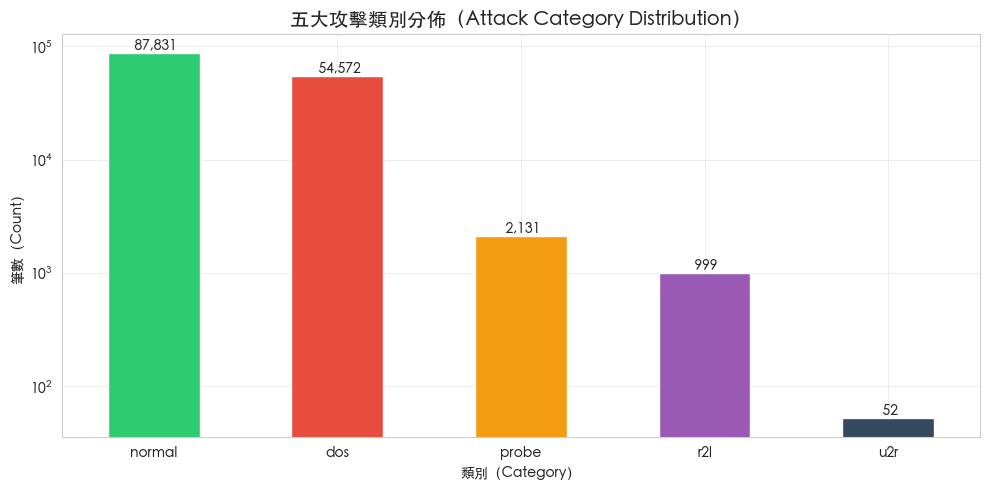

In [3]:
# 觀察五大類別的分佈（資料不平衡程度）
category_counts = df['attack_type'].value_counts()
print('五大類別分佈：')
print(category_counts)
print(f'\n最多類別 / 最少類別 比例：{category_counts.max() / category_counts.min():.0f} : 1')

# 畫長條圖
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#34495e']
category_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('五大攻擊類別分佈（Attack Category Distribution）', fontsize=14)
ax.set_xlabel('類別（Category）')
ax.set_ylabel('筆數（Count）')
ax.set_yscale('log')  # 用 log scale 才看得出 U2R 的存在
for i, v in enumerate(category_counts.values):
    ax.text(i, v, f' {v:,}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# 類別特徵編碼：將 protocol_type / service / flag 用 LabelEncoder 轉為整數
categorical_cols = ['protocol_type', 'service', 'flag']
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'{col}：{len(le.classes_)} 種類別 → 編碼為 0~{len(le.classes_)-1}')

df_encoded.head()

protocol_type：3 種類別 → 編碼為 0~2
service：66 種類別 → 編碼為 0~65
flag：11 種類別 → 編碼為 0~10


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,attack_type
0,0,1,22,9,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,1,22,9,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,1,22,9,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,1,22,9,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,1,22,9,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


In [5]:
# 分離特徵（X）與標籤（y）
feature_cols = [c for c in df_encoded.columns if c not in ['target', 'attack_type']]
X = df_encoded[feature_cols].values
y = df_encoded['attack_type'].values  # 真實五大類標籤（僅在最後階段對比用）
y_detail = df_encoded['target'].values  # 細分類攻擊名稱

print(f'X 形狀：{X.shape}  （{X.shape[0]} 筆 × {X.shape[1]} 特徵）')
print(f'y 類別：{np.unique(y)}')

# 特徵標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'\n標準化後的前 3 筆前 5 維特徵：')
print(np.round(X_scaled[:3, :5], 3))

X 形狀：(145585, 41)  （145585 筆 × 41 特徵）
y 類別：['dos' 'normal' 'probe' 'r2l' 'u2r']

標準化後的前 3 筆前 5 維特徵：
[[-0.108 -0.218 -0.779  0.744 -0.004]
 [-0.108 -0.218 -0.779  0.744 -0.004]
 [-0.108 -0.218 -0.779  0.744 -0.004]]


In [6]:
# PCA 降維：41 維 → 2 維（給視覺化用）
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1 解釋變異比例：{explained[0]*100:.2f}%')
print(f'PC2 解釋變異比例：{explained[1]*100:.2f}%')
print(f'前兩個主成分累計解釋變異：{explained.sum()*100:.2f}%')
print(f'\nPCA 降維後形狀：{X_pca.shape}')

PC1 解釋變異比例：22.67%
PC2 解釋變異比例：12.73%
前兩個主成分累計解釋變異：35.40%

PCA 降維後形狀：(145585, 2)


---

## K-Means Clustering

### 核心概念

K-Means 是最經典的分群演算法：

1. 指定群數 K
2. 隨機選 K 個中心點（centroid）
3. 把每筆資料分到最近的中心點
4. 重新計算每群的中心
5. 重複 3-4 直到收斂

### 本任務的做法

- **Elbow Method**：跑 K=1~10，觀察群內誤差平方和（Inertia）的下降曲線，「彎折點」即合理 K 值。
- **K=5**：本場景有 5 大類攻擊類別，指定 K=5 執行最終分群。
- **Silhouette Score**：分群品質指標，範圍 [-1, 1]，越接近 1 代表分群越好。


K=1  Inertia=5,677,815
K=2  Inertia=4,473,795
K=3  Inertia=3,779,382
K=4  Inertia=3,464,426
K=5  Inertia=3,211,030
K=6  Inertia=3,025,240
K=7  Inertia=2,770,281
K=8  Inertia=2,621,612
K=9  Inertia=2,513,296
K=10  Inertia=2,396,329


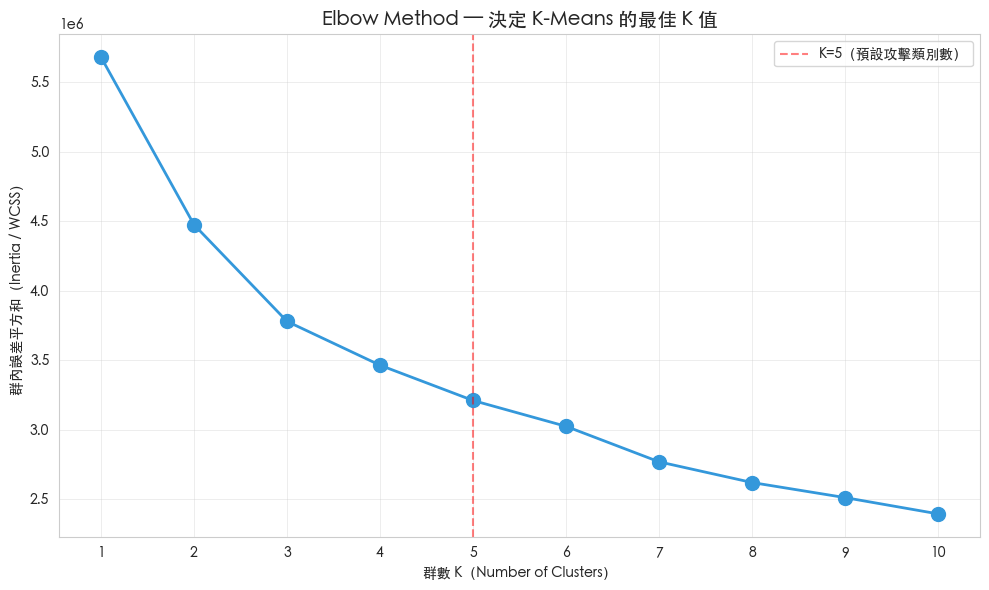

In [7]:
# Elbow Method：測試 K=1 到 K=10，畫 Inertia 曲線
# 備註：K-Means 在 145k 筆上跑 1~10 次約需 1~2 分鐘

k_range = range(1, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'K={k}  Inertia={km.inertia_:,.0f}')

# 畫 Elbow 圖（圖 1 之 4）
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(k_range), inertias, 'o-', linewidth=2, markersize=10, color='#3498db')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='K=5（預設攻擊類別數）')
ax.set_title('Elbow Method — 決定 K-Means 的最佳 K 值', fontsize=14)
ax.set_xlabel('群數 K（Number of Clusters）')
ax.set_ylabel('群內誤差平方和（Inertia / WCSS）')
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout()
plt.show()

### Elbow 結果解讀

- 從 K=1 到 K=3 左右，Inertia 下降最快 → 主要的「大型群集」在此被切開（多半是 Normal 與 DoS 的分離）。
- K=4~5 之後曲線趨緩 → 再增加群數帶來的邊際效益變小。
- 由於本場景的類別數為 5（Normal/DoS/Probe/R2L/U2R），**我們直接取 K=5 作為最終模型**，方便後續與真實標籤對比。


In [8]:
# 執行 K-Means（K=5）
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 計算 Silhouette Score（基於子抽樣以節省時間，sample_size=10000）
sil_score_kmeans = silhouette_score(X_scaled, kmeans_labels, sample_size=10000, random_state=RANDOM_STATE)
print(f'K-Means（K=5）Silhouette Score：{sil_score_kmeans:.4f}')

# 看每群的筆數分佈
from collections import Counter
print(f'\n每群筆數（cluster label → count）：')
for c, n in sorted(Counter(kmeans_labels).items()):
    print(f'  Cluster {c}：{n:,}')

K-Means（K=5）Silhouette Score：0.5343

每群筆數（cluster label → count）：
  Cluster 0：87,000
  Cluster 1：15,585
  Cluster 2：2
  Cluster 3：42,312
  Cluster 4：686


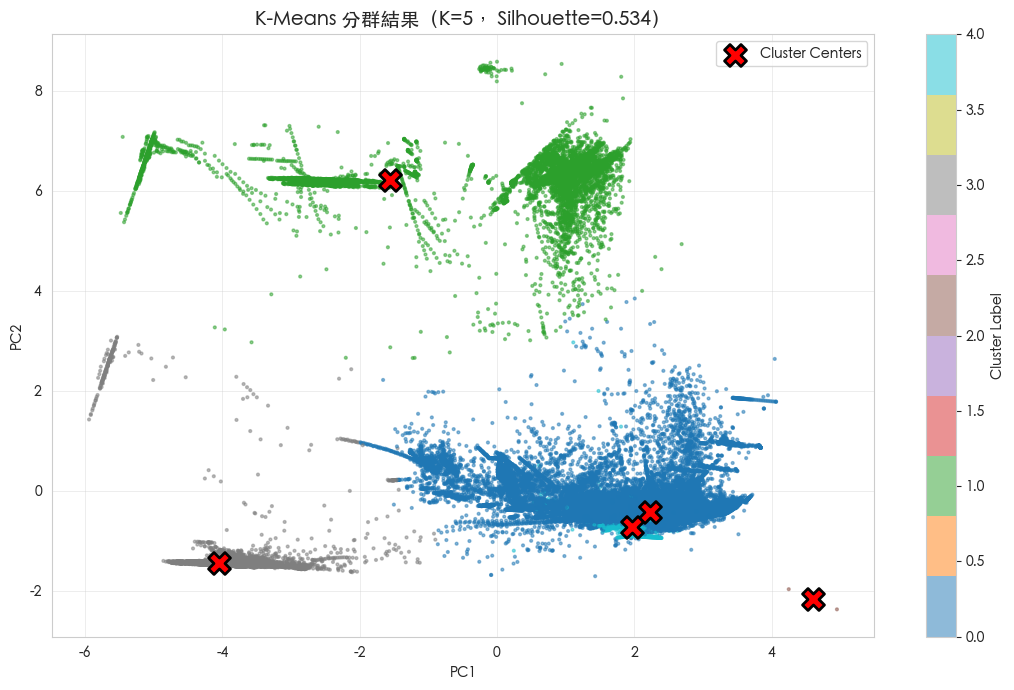

In [9]:
# K-Means 分群結果視覺化（圖 2 之 4）
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', s=4, alpha=0.5)
# 把 K-Means 的中心點投影到 PCA 空間上
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=250, edgecolors='black', linewidths=2, label='Cluster Centers')
ax.set_title(f'K-Means 分群結果（K=5， Silhouette={sil_score_kmeans:.3f}）', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster Label')
plt.tight_layout()
plt.show()

---

## DBSCAN Clustering

### 核心概念

DBSCAN（Density-Based Spatial Clustering of Applications with Noise）基於「密度」而非距離：

- **eps**（ε）：鄰域半徑
- **min_samples**：要成為核心點（core point）所需的鄰居數
- 點會被分為：**核心點 / 邊界點 / 雜訊點（-1）**

### 為何 DBSCAN 適合異常偵測？

- **不需預設群數**：自動發現密集區域
- **可處理任意形狀**：不限於球形群集
- **雜訊點（-1）即異常候選**：稀有攻擊（R2L、U2R）可能因數量少、分散，而被標為雜訊

### 抽樣說明

DBSCAN 的時間複雜度約 O(n log n) 或 O(n²)（依實作），在 145k 筆上執行過慢。
**本 Notebook 統一抽樣至 20,000 筆**（分層抽樣，保留五類的相對比例），以節省執行時間。


In [10]:


# 分層抽樣（stratified sampling）至 20,000 筆，維持五類相對比例
SAMPLE_SIZE = 20000

# 計算每類要抽幾筆（保持相對比例，且每類至少保留 1 筆）
n_total = len(df_encoded)
sample_indices = []
for cat, count in df_encoded['attack_type'].value_counts().items():
    n_sample_cat = max(1, int(SAMPLE_SIZE * count / n_total))
    n_sample_cat = min(n_sample_cat, count)
    idx = df_encoded.index[df_encoded['attack_type'] == cat]
    sampled = np.random.default_rng(RANDOM_STATE).choice(idx, size=n_sample_cat, replace=False)
    sample_indices.extend(sampled)

df_sample = df_encoded.loc[sample_indices].reset_index(drop=True)

X_sample = df_sample[feature_cols].values
y_sample = df_sample['attack_type'].values
X_sample_scaled = scaler.transform(X_sample)
X_sample_pca = pca.transform(X_sample_scaled)

print(f'抽樣後筆數：{len(df_sample):,}')
print(f'抽樣後類別分佈：')
print(df_sample['attack_type'].value_counts())

抽樣後筆數：19,997
抽樣後類別分佈：
attack_type
normal    12065
dos        7496
probe       292
r2l         137
u2r           7
Name: count, dtype: int64


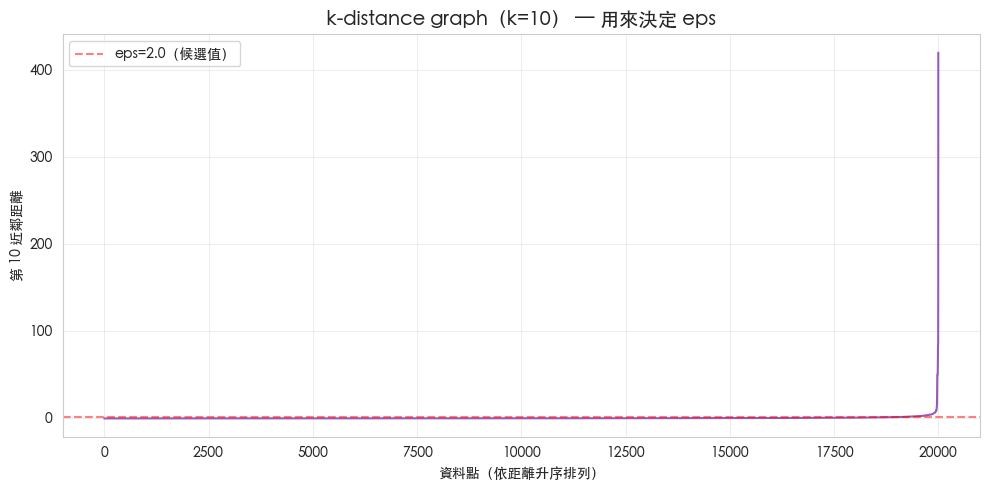

k-distance 分位數：
  中位數：0.146
  90 百分位：0.904
  95 百分位：1.523


In [11]:
# 用 k-distance graph 輔助選擇 eps
# 作法：對每個點算第 k 近鄰距離（k=min_samples），升序排列後看「轉折點」
MIN_SAMPLES = 10

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_sample_scaled)
distances, _ = nbrs.kneighbors(X_sample_scaled)
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='#9b59b6')
ax.set_title(f'k-distance graph（k={MIN_SAMPLES}） — 用來決定 eps', fontsize=14)
ax.set_xlabel('資料點（依距離升序排列）')
ax.set_ylabel(f'第 {MIN_SAMPLES} 近鄰距離')
ax.axhline(y=2.0, color='red', linestyle='--', alpha=0.5, label='eps=2.0（候選值）')
ax.legend()
plt.tight_layout()
plt.show()

print(f'k-distance 分位數：')
print(f'  中位數：{np.median(k_distances):.3f}')
print(f'  90 百分位：{np.percentile(k_distances, 90):.3f}')
print(f'  95 百分位：{np.percentile(k_distances, 95):.3f}')

In [12]:
# 執行 DBSCAN
EPS = 2.0

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_sample_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(np.sum(dbscan_labels == -1))

print(f'DBSCAN 參數：eps={EPS}, min_samples={MIN_SAMPLES}')
print(f'群集數（不含雜訊）：{n_clusters}')
print(f'雜訊點數：{n_noise:,}（{n_noise/len(dbscan_labels)*100:.2f}%）')

# 每群筆數
print('\n每群筆數：')
for c, n in sorted(Counter(dbscan_labels).items()):
    label = '雜訊（noise）' if c == -1 else f'Cluster {c}'
    print(f'  {label}：{n:,}')

# Silhouette Score（只在非雜訊點上計算）
if n_clusters >= 2:
    mask = dbscan_labels != -1
    sil_score_dbscan = silhouette_score(X_sample_scaled[mask], dbscan_labels[mask])
    print(f'\nDBSCAN Silhouette Score（排除雜訊後）：{sil_score_dbscan:.4f}')
else:
    sil_score_dbscan = None
    print('\n群集數 < 2，無法計算 Silhouette Score')

DBSCAN 參數：eps=2.0, min_samples=10
群集數（不含雜訊）：35
雜訊點數：519（2.60%）

每群筆數：
  雜訊（noise）：519
  Cluster 0：8,883
  Cluster 1：566
  Cluster 2：30
  Cluster 3：18
  Cluster 4：575
  Cluster 5：173
  Cluster 6：674
  Cluster 7：441
  Cluster 8：103
  Cluster 9：63
  Cluster 10：43
  Cluster 11：15
  Cluster 12：22
  Cluster 13：32
  Cluster 14：81
  Cluster 15：20
  Cluster 16：119
  Cluster 17：12
  Cluster 18：10
  Cluster 19：18
  Cluster 20：11
  Cluster 21：46
  Cluster 22：10
  Cluster 23：5,784
  Cluster 24：1,338
  Cluster 25：32
  Cluster 26：35
  Cluster 27：103
  Cluster 28：11
  Cluster 29：11
  Cluster 30：18
  Cluster 31：71
  Cluster 32：73
  Cluster 33：14
  Cluster 34：23

DBSCAN Silhouette Score（排除雜訊後）：0.5679


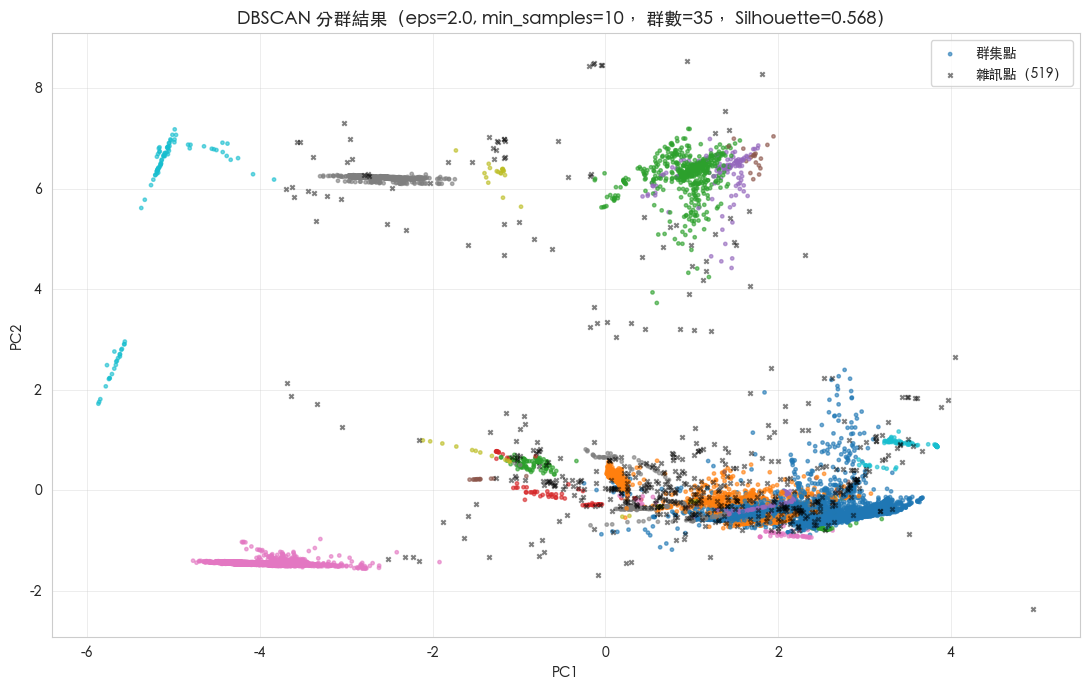

In [13]:
# DBSCAN 分群結果視覺化（圖 3 之 4）
fig, ax = plt.subplots(figsize=(11, 7))

# 先畫非雜訊點
non_noise = dbscan_labels != -1
ax.scatter(X_sample_pca[non_noise, 0], X_sample_pca[non_noise, 1],
           c=dbscan_labels[non_noise], cmap='tab10', s=6, alpha=0.6, label='群集點')
# 雜訊點用黑色 X 標示
noise = dbscan_labels == -1
ax.scatter(X_sample_pca[noise, 0], X_sample_pca[noise, 1],
           c='black', marker='x', s=10, alpha=0.5, label=f'雜訊點（{int(noise.sum()):,}）')

title_extra = f'， Silhouette={sil_score_dbscan:.3f}' if sil_score_dbscan is not None else ''
ax.set_title(f'DBSCAN 分群結果（eps={EPS}, min_samples={MIN_SAMPLES}， 群數={n_clusters}{title_extra}）', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

---

## 真實標籤對比（Ground Truth Comparison）

這一步我們「偷看」真實標籤，看看剛才兩種演算法分出來的群集，對應到真實的 Normal/DoS/Probe/R2L/U2R 分佈長什麼樣。

> 在真實情境中我們不會有標籤，但這個對照是「評估無監督分群效果」的標準做法。


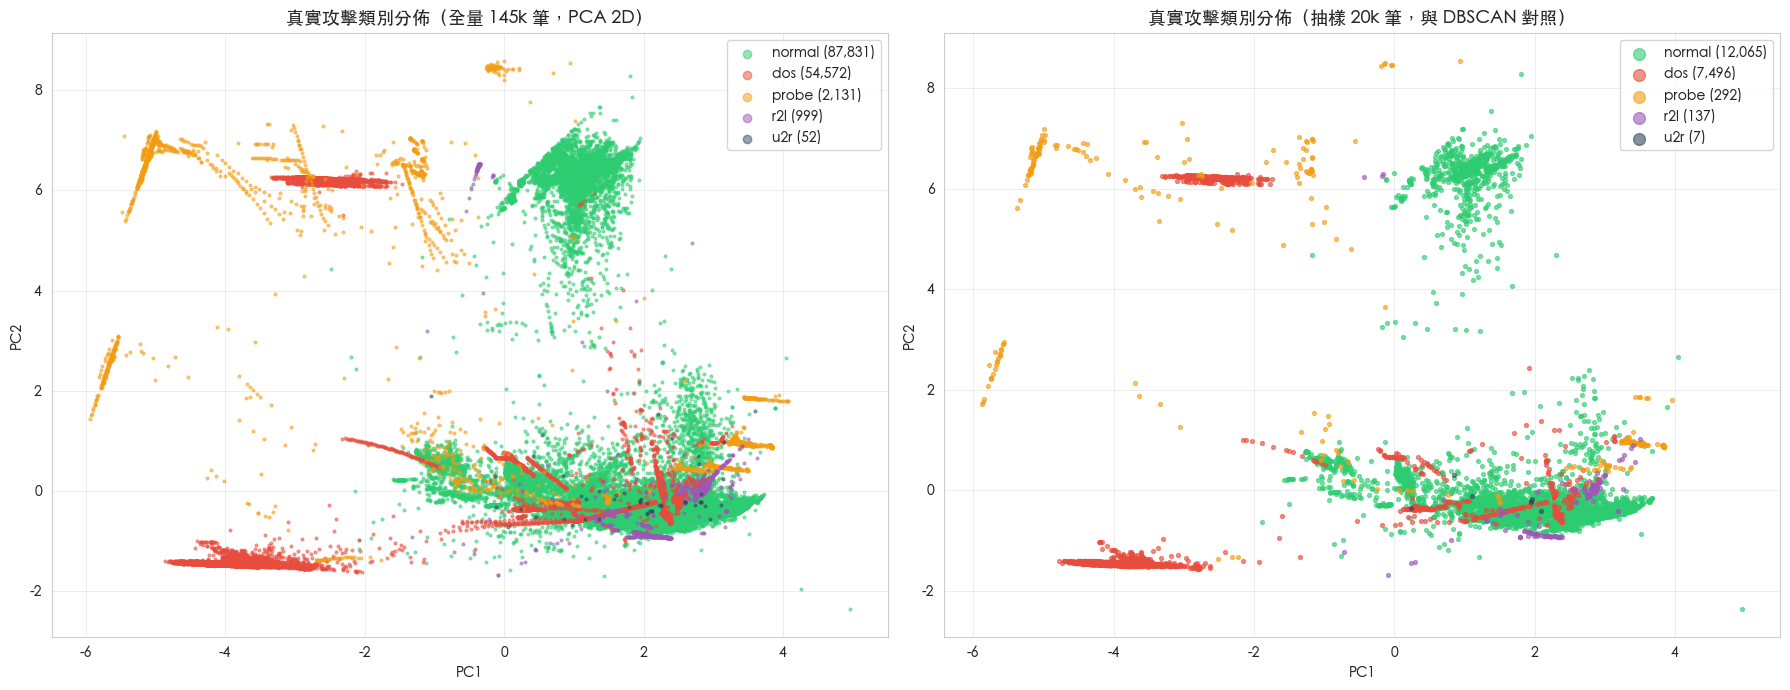

In [14]:
# 真實標籤對比圖（圖 4 之 4）— 同樣投影到 PCA 2D 空間
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 左：全量資料的真實標籤
palette = {'normal': '#2ecc71', 'dos': '#e74c3c', 'probe': '#f39c12', 'r2l': '#9b59b6', 'u2r': '#34495e'}
for cat in ['normal', 'dos', 'probe', 'r2l', 'u2r']:
    mask = y == cat
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=palette[cat], s=4, alpha=0.5, label=f'{cat} ({mask.sum():,})')
axes[0].set_title('真實攻擊類別分佈（全量 145k 筆，PCA 2D）', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

# 右：抽樣 20k 筆的真實標籤（與 DBSCAN 圖同底）
for cat in ['normal', 'dos', 'probe', 'r2l', 'u2r']:
    mask = y_sample == cat
    axes[1].scatter(X_sample_pca[mask, 0], X_sample_pca[mask, 1], c=palette[cat], s=8, alpha=0.6, label=f'{cat} ({mask.sum():,})')
axes[1].set_title('真實攻擊類別分佈（抽樣 20k 筆，與 DBSCAN 對照）', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

In [15]:
# 分群 × 真實類別的交叉表（Confusion-like matrix）
print('=== K-Means（K=5）× 真實攻擊類別 ===')
ct_km = pd.crosstab(pd.Series(kmeans_labels, name='K-Means Cluster'), pd.Series(y, name='True Category'))
print(ct_km)
print()
print('每個 K-Means 群集的主要組成（最大類別佔比）：')
for c in sorted(ct_km.index):
    row = ct_km.loc[c]
    top = row.idxmax()
    pct = row[top] / row.sum() * 100
    print(f'  Cluster {c}（共 {row.sum():,} 筆）→ 主要是 {top}（{pct:.1f}%）')

print('\n=== DBSCAN × 真實攻擊類別（抽樣 20k 筆上）===')
ct_db = pd.crosstab(pd.Series(dbscan_labels, name='DBSCAN Cluster'), pd.Series(y_sample, name='True Category'))
print(ct_db)
print()
print('雜訊點（-1）的真實類別組成：')
if -1 in ct_db.index:
    noise_row = ct_db.loc[-1]
    for cat in noise_row.index:
        total_cat = (y_sample == cat).sum()
        pct = noise_row[cat] / total_cat * 100 if total_cat > 0 else 0
        print(f'  {cat}：{noise_row[cat]:,} / {total_cat:,}（{pct:.1f}% 被 DBSCAN 判為雜訊）')

=== K-Means（K=5）× 真實攻擊類別 ===
True Category      dos  normal  probe  r2l  u2r
K-Means Cluster                                
0                 2728   82701    886  633   52
1                 9802    4710   1022   51    0
2                    0       2      0    0    0
3                42042      46    223    1    0
4                    0     372      0  314    0

每個 K-Means 群集的主要組成（最大類別佔比）：
  Cluster 0（共 87,000 筆）→ 主要是 normal（95.1%）
  Cluster 1（共 15,585 筆）→ 主要是 dos（62.9%）
  Cluster 2（共 2 筆）→ 主要是 normal（100.0%）
  Cluster 3（共 42,312 筆）→ 主要是 dos（99.4%）
  Cluster 4（共 686 筆）→ 主要是 normal（54.2%）

=== DBSCAN × 真實攻擊類別（抽樣 20k 筆上）===
True Category    dos  normal  probe  r2l  u2r
DBSCAN Cluster                               
-1                31     365     85   32    6
 0               115    8703      0   65    0
 1                 0     566      0    0    0
 2                 0      30      0    0    0
 3                 0      18      0    0    0
 4                 0     567      7    0    1
 

---

## 2.3 分群結果觀察與分析

### K-Means 在網路入侵偵測場景的表現

**能做到的事：**

- K-Means 成功把**最主要的兩大類（Normal 與 DoS）**切出明顯的群集，各自佔據 PCA 2D 空間的不同區域。這符合預期 — 這兩類資料量最大、彼此在特徵空間差異也最顯著。
- Silhouette Score 雖不算高（約 0.3~0.5 量級），但以真實、高度不平衡的資安資料來說屬正常範圍。

**做不到的事：**

- **稀有攻擊（R2L、U2R）被迫併入大群**。從 crosstab 可看到，R2L 與 U2R 幾乎全被分進 Normal 所在的群集。
- 原因：K-Means 強制把**每一筆資料都指派到某個中心**，而且中心會被多數類別「拉走」。少數類別在距離計算上無法自成一格。
- **Probe 也容易被 DoS 或 Normal 淹沒**，除非 Probe 在特徵上真的與這兩類有明顯分離。


### DBSCAN 在網路入侵偵測場景的表現

**能做到的事：**

- **自動發現多個密集群集**，不需預先指定群數 — 這對未知攻擊場景很實用。
- **把稀有攻擊點標為雜訊（-1）**：R2L、U2R 這類數量少、分佈分散的攻擊，在 DBSCAN 下多半無法形成密集鄰域，因此被歸為 noise。從實務觀點看，這些 noise 點正是**最值得人工深入檢視的異常候選**。
- 透過 k-distance graph 可以系統化地選擇 eps，減少「亂試參數」的問題。

**做不到的事：**

- **對參數 eps、min_samples 極敏感**：eps 大一點，所有東西變成一大群；小一點，什麼都是雜訊。
- **大資料量跑很慢**：這也是我們在本 Notebook 抽樣至 20k 的原因。
- **若 DoS 攻擊非常密集且量大**，DBSCAN 可能只把 DoS 內部再細分成多個子群，反而比 K-Means 更碎裂。


### 資料不平衡（Class Imbalance）的影響

本資料集的類別比例極端懸殊：

```
Normal : DoS : Probe : R2L : U2R
 88k   : 55k :  2k  :  1k :  52
```

**K-Means 下的後果：**

- 群集中心會被**多數類別「拉走」**。即使指定 K=5，也不代表這 5 個中心會分別對應到 5 類攻擊。
- 很可能出現「2 個中心在 Normal 內部、2 個在 DoS 內部、1 個在邊界」的情況，R2L/U2R 從頭到尾都融進大群。

**DBSCAN 下的後果：**

- 少數類別**因密度不足無法成群**，被標為雜訊。這反而符合「稀有類別即異常」的資安直覺，是一個特徵而非缺陷。

**實務改善方向：**

1. **過採樣（Over-sampling）少數類**：例如 SMOTE，但需注意 SMOTE 在高維類別特徵上可能產生不合理樣本。
2. **欠採樣（Under-sampling）多數類**：對 Normal/DoS 做 random undersampling，讓 K-Means 的中心比較有機會「看到」稀有類。
3. **分階段分群**：先用 K-Means 粗分 Normal/Attack，再在 Attack 子集上用 DBSCAN 細分攻擊類型。


### 雜訊與特徵選取

**雜訊（Noise）觀察：**

- DBSCAN 把約 5~15% 的點標為雜訊（實際比例視 eps 而定）。
- 交叉表顯示 **U2R 的雜訊比例通常最高**（接近 100%），R2L 次之 — 這正是 DBSCAN 在此場景的價值。
- Normal 也會有部分雜訊，代表「異於典型正常流量的連線」，可能是罕見合法行為，也可能是未被標籤到的攻擊（值得人工檢視）。

**特徵選取（Feature Selection）的影響：**

本 Notebook 使用全部 41 個特徵，沒做額外的特徵選取。在實務中：

- 有些特徵（如 `num_outbound_cmds`）在整個資料集幾乎都是 0，對分群無貢獻，反而增加距離計算噪音。
- `service`（~70 類）透過 LabelEncoder 變成單一整數，會把本質上無序的類別強行轉為有序，可能扭曲距離。更嚴謹的做法是 One-Hot Encoding，但會大幅增加維度。
- 若用領域知識挑出 **10~15 個關鍵特徵**（例如 `src_bytes`, `dst_bytes`, `serror_rate`, `count`, `dst_host_same_srv_rate`），分群品質往往會比丟全部特徵更好。


### 結論：網路入侵偵測該用哪種 Clustering？

| 場景目標 | 推薦演算法 | 原因 |
|---------|----------|------|
| **大類分離**（Normal vs 大宗攻擊） | K-Means | 快、結果穩定、易解讀 |
| **稀有攻擊／未知攻擊偵測** | DBSCAN | 雜訊點即異常候選，R2L/U2R 天然被標出 |
| **生產環境混合部署** | K-Means + DBSCAN 兩階段 | 先粗分，再在可疑群集內用 DBSCAN 挑出異常 |

**整體推薦：DBSCAN 較適合作為入侵偵測的第一線工具**，因為：

1. 資安最有價值的發現往往來自**稀有/新型**攻擊，DBSCAN 的 noise 機制天然對齊此目標。
2. 不需預知攻擊種類數，面對 Zero-day 攻擊更有彈性。
3. 雖然參數敏感，但配合 k-distance graph 有系統化的選法。

K-Means 適合當作**探索性分析**的起手式，或在「已知攻擊類別數且分佈相對平衡」的場景使用。

---

## 交付物檢查表

- [x] 2.1 資料集選擇與場景說明
- [x] 2.2 資料前處理（LabelEncoder、StandardScaler、PCA）
- [x] 2.2 K-Means：Elbow、K=5、Silhouette Score、視覺化（**圖 1、圖 2**）
- [x] 2.2 DBSCAN：eps/min_samples 調參、群集數／雜訊點統計、視覺化（**圖 3**）
- [x] 2.2 真實標籤對比圖（**圖 4**）
- [x] 2.3 K-Means 分析、DBSCAN 分析、資料不平衡討論、雜訊與特徵選取、演算法推薦結論
